# Multi-variable Linear Regression - Building Everything From Scratch

## Imports

In [58]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd

In [59]:
import models
import toolkit
import preprocessing

importlib.reload(models)
importlib.reload(toolkit)
importlib.reload(preprocessing)

from models import *
from toolkit import *
from preprocessing import SalaryDataPreprocessor

## Data Loading, Cleaning and Preparation

In [60]:
df = pd.read_csv("./datasets/Salary_Data.csv")

print("Original dataset size: ", len(df))

Original dataset size:  6704


### Dropping rows containing NAN value

In [61]:
df.isna().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [62]:
dropped_rows = df[df.isnull().any(axis=1)]
df = df.dropna()

print("Number of dropped rows: ", len(dropped_rows))

Number of dropped rows:  6


### Splitting Dataset

In [65]:
df_train, df_test = DatasetKit.split_dataset(df, 0.8)

display(df_train)
display(df_test)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
1106,31.0,Male,Master's,Data Scientist,9.0,185000.0
1629,38.0,Male,Master's Degree,Senior Software Engineer,10.0,155000.0
830,32.0,Male,Bachelor's,Software Engineer,8.0,190000.0
3177,32.0,Male,Master's Degree,Product Manager,7.0,110000.0
4008,25.0,Female,Bachelor's Degree,Junior Software Developer,1.0,35000.0
...,...,...,...,...,...,...
4297,31.0,Male,Bachelor's Degree,Software Developer,6.0,85000.0
5351,35.0,Female,PhD,Research Director,11.0,160000.0
3307,28.0,Male,Bachelor's Degree,Software Engineer,4.0,75000.0
6026,36.0,Male,PhD,Research Scientist,13.0,185000.0


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
5267,35.0,Female,PhD,Research Director,11.0,160000.0
2481,57.0,Female,PhD,Software Engineer Manager,33.0,191790.0
3916,30.0,Male,Bachelor's Degree,Software Engineer,4.0,65000.0
5217,24.0,Female,High School,Sales Associate,0.0,25000.0
4405,35.0,Female,Master's Degree,Human Resources Manager,8.0,92000.0
...,...,...,...,...,...,...
2192,33.0,Male,Bachelor's Degree,Full Stack Engineer,7.0,130000.0
4806,34.0,Male,Master's Degree,Senior Data Scientist,9.0,125000.0
5673,24.0,Female,High School,Receptionist,0.0,25000.0
5734,29.0,Male,Bachelor's Degree,Marketing Analyst,4.0,70000.0


### Job Title Encoding

Job titles were target-encoded (mean-encoded) using the target variable `Salary`.

To prevent the **Rare Label Trap** (where categories with low occurrence heavily overfit to anomalous target values), job titles with a frequency of **`<= 10`** were bucketed into a single `"Other"` category before calculating the mean salary.

*(Note: Target Encoding natively transforms the label into a continuous floating point float.)*

In [93]:
preprocessor = SalaryDataPreprocessor()

assert isinstance(df_train, pd.DataFrame)
df_train_fit = preprocessor.fit_transform(df_train)

In [67]:
df_clean_train = df_train_fit[["Age", "Gender_ID", "Education_Level_ID", "Job_Title_ID", "Years of Experience", "Salary"]]

df_clean_train

,Age,Gender_ID,Education_Level_ID,Job_Title_ID,Years of Experience,Salary
1106,31.0,0,2,166645.945946,9.0,185000.0
1629,38.0,0,2,151958.242574,10.0,155000.0
830,32.0,0,1,112544.794189,8.0,190000.0
3177,32.0,0,2,142004.184100,7.0,110000.0
4008,25.0,1,1,35872.340426,1.0,35000.0
...,...,...,...,...,...,...
4297,31.0,0,1,64230.769231,6.0,85000.0
5351,35.0,1,3,162857.142857,11.0,160000.0
3307,28.0,0,1,112544.794189,4.0,75000.0
6026,36.0,0,3,164833.333333,13.0,185000.0


### Report Summary (Data Changes)

- Original loaded dataset shape: **(6704, 6)**.
- Removed **6 rows** containing missing values, resulting in **(6698, 6)**.
- Splitting dataset **80/20 train/test** ratio resulting in `df_train` **(5358, 6)** and `df_test` **(1340, 6)**.
- Fit and Transform **`df_train`** dynamically utilizing a modularized `preprocessing` object (added encoded feature columns: `Job_Title_ID`, `Gender_ID`, and `Education_Level_ID`).
- Dropped **11** rows from `df_train` with invalid mapped `Gender` value resulting in **(5347, 9)**.
- Final engineering subset shape via `df_clean_train`: **(5347, 6)** separating `Salary` as the target label.

- **Features**: `Age`, `Gender_ID`, `Education_Level_ID`, `Job_Title_ID`, `Years_of_Experience`
- **Label**: `Salary`

## Correlation Matrix of Features

In [68]:
age = df_clean_train["Age"].to_numpy(dtype=np.float64)
gender = df_clean_train["Gender_ID"].to_numpy(dtype=np.float64)
education = df_clean_train["Education_Level_ID"].to_numpy(dtype=np.float64)
job_title = df_clean_train["Job_Title_ID"].to_numpy(dtype=np.float64)
experience = df_clean_train["Years of Experience"].to_numpy(dtype=np.float64)

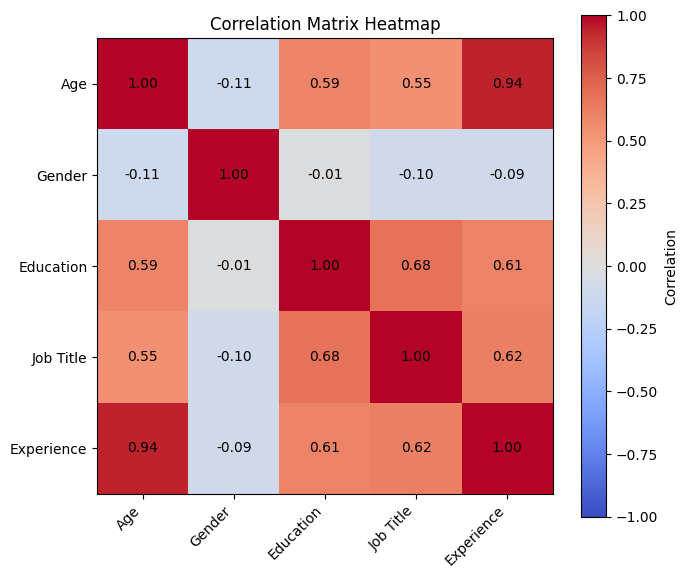

In [69]:
# 1) Build matrix
labels = ["Age", "Gender", "Education", "Job Title", "Experience"]
datasets = [age, gender, education, job_title, experience]

# 2) Plot heatmap
StatKit.plot_corr_matrix_heatmap(datasets, labels)


In [70]:
df_model = df_clean_train.drop(labels=["Age"], axis=1)

## Model Training, Prediction and Evaluation

In [71]:
model = MultiLinearRegression()

In [76]:
X_train = df_model.drop(labels=["Salary"], axis=1).to_numpy(dtype=np.float64)
y_train = df_model["Salary"].to_numpy(dtype=np.float64)

In [85]:
model.train(X_train, y_train, fit_intercept=True)

In [81]:
assert isinstance(df_test, pd.DataFrame)

df_test_fit = preprocessor.transform(df_test)

df_clean_test = df_test_fit[["Age", "Gender_ID", "Education_Level_ID", "Job_Title_ID", "Years of Experience", "Salary"]]

df_clean_test

,Age,Gender_ID,Education_Level_ID,Job_Title_ID,Years of Experience,Salary
5267,35.0,1,3,162857.142857,11.0,160000.0
2481,57.0,1,3,172840.729167,33.0,191790.0
3916,30.0,0,1,112544.794189,4.0,65000.0
5217,24.0,1,0,36666.666667,0.0,25000.0
4405,35.0,1,2,109870.588235,8.0,92000.0
...,...,...,...,...,...,...
2192,33.0,0,1,124675.298319,7.0,130000.0
4806,34.0,0,2,152555.555556,9.0,125000.0
5673,24.0,1,0,25000.000000,0.0,25000.0
5734,29.0,0,1,63240.740741,4.0,70000.0


In [89]:
X_test = df_clean_test.drop(columns=["Age", "Salary"]).to_numpy(dtype=np.float64)
y_test = df_clean_test["Salary"].to_numpy(dtype=np.float64)

print(X_test)
print(y_test)

[[1.00000000e+00 3.00000000e+00 1.62857143e+05 1.10000000e+01]
 [1.00000000e+00 3.00000000e+00 1.72840729e+05 3.30000000e+01]
 [0.00000000e+00 1.00000000e+00 1.12544794e+05 4.00000000e+00]
 ...
 [1.00000000e+00 0.00000000e+00 2.50000000e+04 0.00000000e+00]
 [0.00000000e+00 1.00000000e+00 6.32407407e+04 4.00000000e+00]
 [0.00000000e+00 3.00000000e+00 1.72840729e+05 1.80000000e+01]]
[160000. 191790.  65000. ...  25000.  70000. 210000.]


In [91]:
y_pred = model.predict(X_test)

In [92]:
print("MAE", ModelMetrics.mean_absolute_error(y_pred, y_test))
print("R^2", ModelMetrics.r_squared(y_pred, y_test))

MAE 17282.271868678105
R^2 0.7910063966073121
